# 03 - Baseline Models

## Objective: 
- Train and compare supervised baseline models for credit card fraud detection using a proper validation workflow.

Models:

- Logistic Regression
- Random Forest
- Gradient Boosting

- The validation set is used for threshold tuning and model selection. The test set is used only once for final evaluation.

In [12]:
import pandas as pd
import numpy as np
from pathlib import Path
import joblib
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    precision_recall_curve,
)

RANDOM_STATE = 42

## Load Processed Data

In [13]:
data_path = Path("../outputs/results_corrected/creditcard_cleaned.pkl")
data = joblib.load(data_path)

X_train = data["X_train"]
X_val = data["X_val"]
X_test = data["X_test"]
y_train = data["y_train"]
y_val = data["y_val"]
y_test = data["y_test"]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (198608, 30)
X_val: (42559, 30)
X_test: (42559, 30)


## Evaluation Helpers

In [14]:
def evaluate_scores(model_name, y_true, y_score, threshold):
    y_pred = (y_score >= threshold).astype(int)
    return {
        "Model": model_name,
        "Threshold": threshold,
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_score),
        "PR_AUC": average_precision_score(y_true, y_score),
        "TN": confusion_matrix(y_true, y_pred).ravel()[0],
        "FP": confusion_matrix(y_true, y_pred).ravel()[1],
        "FN": confusion_matrix(y_true, y_pred).ravel()[2],
        "TP": confusion_matrix(y_true, y_pred).ravel()[3],
    }


def tune_threshold(model_name, y_true, y_score, thresholds):
    rows = [evaluate_scores(model_name, y_true, y_score, threshold) for threshold in thresholds]
    return pd.DataFrame(rows)


def print_final_report(model_name, y_true, y_score, threshold):
    y_pred = (y_score >= threshold).astype(int)
    print(f"===== {model_name} | threshold = {threshold:.3f} =====")
    print(classification_report(y_true, y_pred, digits=4, zero_division=0))
    print("Confusion matrix:")
    print(confusion_matrix(y_true, y_pred))

## Candidate Model Configurations

In [15]:
candidate_models = {
    "Logistic Regression - balanced": LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_STATE,
    ),
    "Random Forest - balanced": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Random Forest - shallow": RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Gradient Boosting - default": GradientBoostingClassifier(
        random_state=RANDOM_STATE,
    ),
    "Gradient Boosting - tuned": GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE,
    ),
}

## Train Models and Evaluate Default Threshold on Validation Set

In [16]:
trained_models = {}
validation_scores = {}
default_threshold_results = []

for model_name, model in candidate_models.items():
    print("Training:", model_name)
    model.fit(X_train, y_train)
    trained_models[model_name] = model
    validation_scores[model_name] = model.predict_proba(X_val)[:, 1]
    default_threshold_results.append(
        evaluate_scores(model_name, y_val, validation_scores[model_name], threshold=0.5)
    )

default_threshold_df = pd.DataFrame(default_threshold_results).sort_values("PR_AUC", ascending=False)
default_threshold_df

Training: Logistic Regression - balanced
Training: Random Forest - balanced
Training: Random Forest - shallow
Training: Gradient Boosting - default
Training: Gradient Boosting - tuned


,Model,Threshold,Precision,Recall,F1,ROC_AUC,PR_AUC,TN,FP,FN,TP
1,Random Forest - balanced,0.5,0.950000,0.802817,0.870229,0.969610,0.855017,42485,3,14,57
2,Random Forest - shallow,0.5,0.855072,0.830986,0.842857,0.980311,0.839490,42478,10,12,59
0,Logistic Regression - balanced,0.5,0.061090,0.915493,0.114537,0.976608,0.719676,41489,999,6,65
4,Gradient Boosting - tuned,0.5,0.818182,0.633803,0.714286,0.823772,0.590151,42478,10,26,45
3,Gradient Boosting - default,0.5,0.911765,0.436620,0.590476,0.583607,0.418356,42485,3,40,31


## Threshold Tuning on Validation Set

Threshold tuning is performed only on the validation set. The selected model and threshold will then be evaluated once on the test set.

In [17]:
thresholds = np.round(np.arange(0.05, 0.96, 0.05), 2)

threshold_dfs = []
for model_name, scores in validation_scores.items():
    threshold_dfs.append(tune_threshold(model_name, y_val, scores, thresholds))

validation_threshold_df = pd.concat(threshold_dfs, ignore_index=True)
validation_threshold_df.sort_values(["F1", "PR_AUC"], ascending=False).head(15)

,Model,Threshold,Precision,Recall,F1,ROC_AUC,PR_AUC,TN,FP,FN,TP
25,Random Forest - balanced,0.35,0.936508,0.830986,0.880597,0.969610,0.855017,42484,4,12,59
27,Random Forest - balanced,0.45,0.950820,0.816901,0.878788,0.969610,0.855017,42485,3,13,58
24,Random Forest - balanced,0.30,0.909091,0.845070,0.875912,0.969610,0.855017,42482,6,11,60
26,Random Forest - balanced,0.40,0.935484,0.816901,0.872180,0.969610,0.855017,42484,4,13,58
28,Random Forest - balanced,0.50,0.950000,0.802817,0.870229,0.969610,0.855017,42485,3,14,57
23,Random Forest - balanced,0.25,0.895522,0.845070,0.869565,0.969610,0.855017,42481,7,11,60
49,Random Forest - shallow,0.60,0.907692,0.830986,0.867647,0.980311,0.839490,42482,6,12,59
29,Random Forest - balanced,0.55,0.949153,0.788732,0.861538,0.969610,0.855017,42485,3,15,56
30,Random Forest - balanced,0.60,0.964912,0.774648,0.859375,0.969610,0.855017,42486,2,16,55
50,Random Forest - shallow,0.65,0.906250,0.816901,0.859259,0.980311,0.839490,42482,6,13,58


## Select Best Supervised Baseline Model

- The selected baseline is the model-threshold pair with the highest validation F1 score.

In [18]:
best_validation_row = (
    validation_threshold_df
    .sort_values(["F1", "PR_AUC", "Recall"], ascending=False)
    .iloc[0]
)

best_model_name = best_validation_row["Model"]
best_threshold = float(best_validation_row["Threshold"])
best_model = trained_models[best_model_name]

print("Selected supervised model:", best_model_name)
print("Selected threshold:", best_threshold)
best_validation_row

Selected supervised model: Random Forest - balanced
Selected threshold: 0.35


Model        Random Forest - balanced
Threshold                        0.35
Precision                    0.936508
Recall                       0.830986
F1                           0.880597
ROC_AUC                       0.96961
PR_AUC                       0.855017
TN                              42484
FP                                  4
FN                                 12
TP                                 59
Name: 25, dtype: object

## Final Test Evaluation using the test dataset

- expects unbiased results

In [19]:
test_scores = best_model.predict_proba(X_test)[:, 1]
test_result = evaluate_scores(best_model_name, y_test, test_scores, best_threshold)
test_results_df = pd.DataFrame([test_result])

print_final_report(best_model_name, y_test, test_scores, best_threshold)
test_results_df

===== Random Forest - balanced | threshold = 0.350 =====
              precision    recall  f1-score   support

           0     0.9995    0.9999    0.9997     42488
           1     0.9259    0.7042    0.8000        71

    accuracy                         0.9994     42559
   macro avg     0.9627    0.8521    0.8999     42559
weighted avg     0.9994    0.9994    0.9994     42559

Confusion matrix:
[[42484     4]
 [   21    50]]


,Model,Threshold,Precision,Recall,F1,ROC_AUC,PR_AUC,TN,FP,FN,TP
0,Random Forest - balanced,0.35,0.925926,0.704225,0.8,0.941271,0.81567,42484,4,21,50


## Curves for Selected Supervised Model

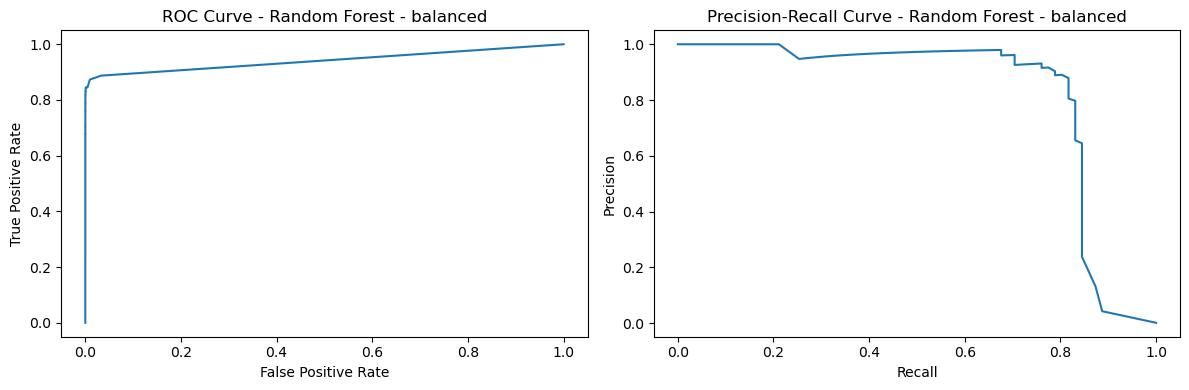

In [20]:
fpr, tpr, _ = roc_curve(y_test, test_scores)
precision, recall, _ = precision_recall_curve(y_test, test_scores)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(fpr, tpr)
axes[0].set_title(f"ROC Curve - {best_model_name}")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")

axes[1].plot(recall, precision)
axes[1].set_title(f"Precision-Recall Curve - {best_model_name}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")

plt.tight_layout()
plt.show()

## Saved Supervised Result Figures

These report-ready plots save the selected supervised model's ROC/PR curves and confusion matrix using the final test set.


D:\Development_Studio\Python_Studio\ACML\Project\outputs\figures\supervised_selected_model_roc_pr_curves.png


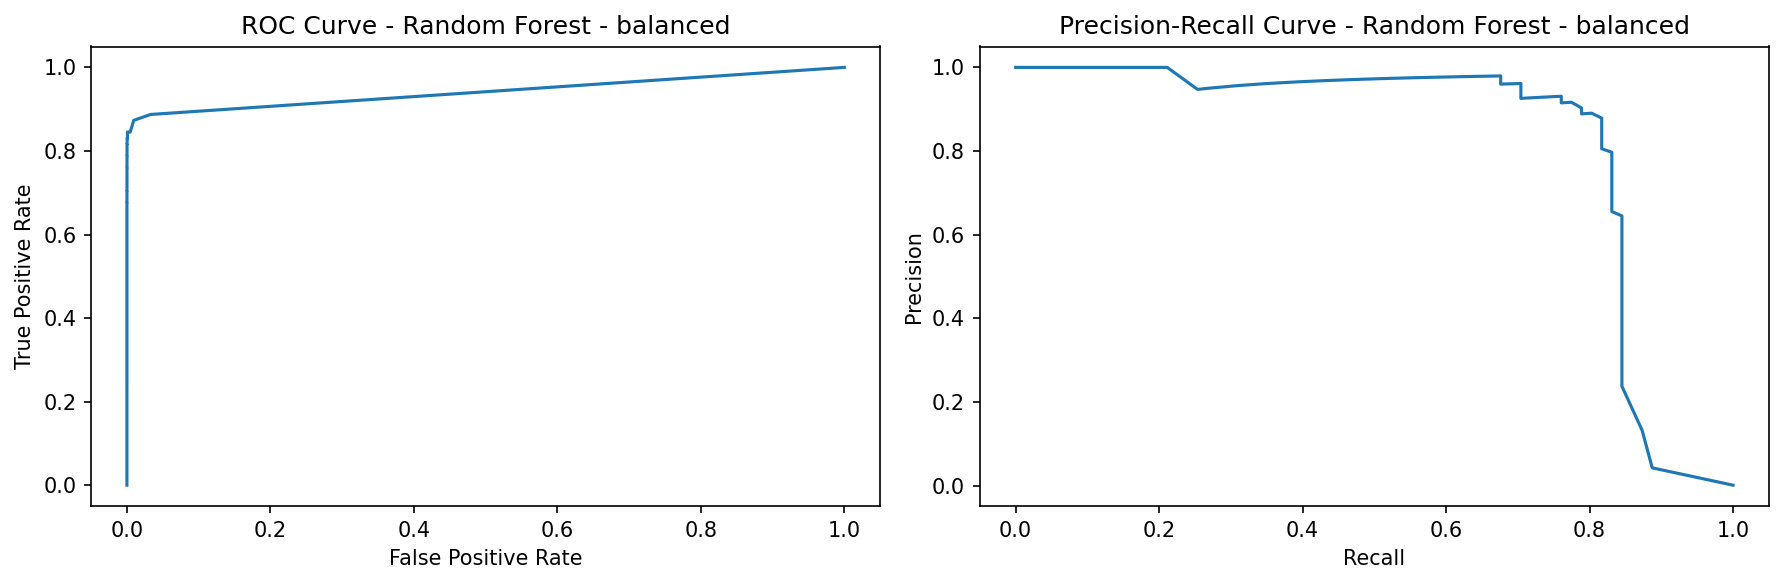

D:\Development_Studio\Python_Studio\ACML\Project\outputs\figures\supervised_selected_model_confusion_matrix.png


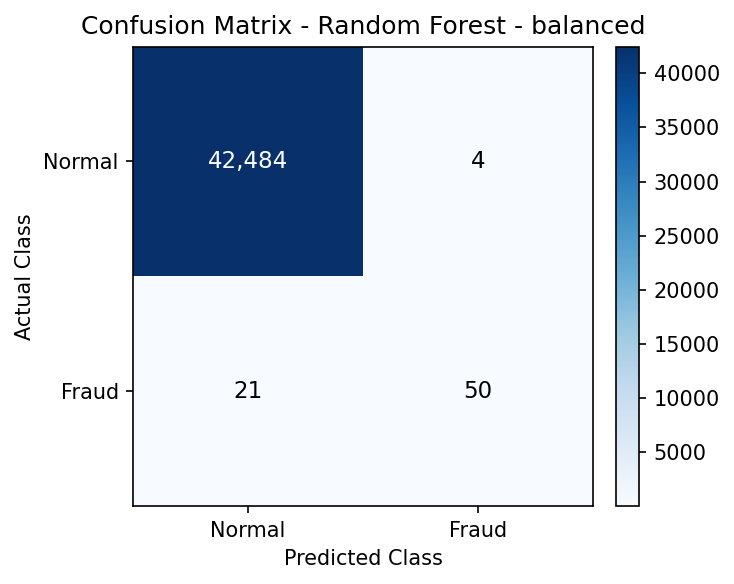

In [21]:
import sys
from IPython.display import Image, display

project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.evaluation import save_confusion_matrix_plot, save_roc_pr_curves

figures_dir = project_root / "outputs" / "figures"
saved_supervised_figures = [
    save_roc_pr_curves(
        y_test,
        test_scores,
        best_model_name,
        figures_dir,
        "supervised_selected_model",
    ),
    save_confusion_matrix_plot(
        y_test,
        test_scores,
        best_threshold,
        best_model_name,
        figures_dir,
        "supervised_selected_model",
    ),
]

for figure_path in saved_supervised_figures:
    print(figure_path)
    display(Image(filename=str(figure_path)))


## Supervised Model Figure Interpretation

The ROC curve shows that the selected Random Forest ranks fraud cases well across thresholds, but the precision-recall curve is more important for this dataset because fraud is extremely rare. The precision-recall behaviour supports the final threshold choice because it keeps precision high while maintaining useful recall.

The Random Forest confusion matrix shows `50` true fraud detections, `21` missed fraud cases, and only `4` false positives on the test set. This is a strong practical result because false positives are very low while recall remains reasonable.


## Save Results

In [22]:
output_path = Path("../outputs/results_corrected")
output_path.mkdir(parents=True, exist_ok=True)

default_threshold_df.to_csv(output_path / "baseline_validation_default_threshold.csv", index=False)
validation_threshold_df.to_csv(output_path / "baseline_validation_threshold_tuning.csv", index=False)
test_results_df.to_csv(output_path / "baseline_test_results.csv", index=False)

joblib.dump(
    {
        "trained_models": trained_models,
        "best_model_name": best_model_name,
        "best_threshold": best_threshold,
        "best_validation_row": best_validation_row.to_dict(),
    },
    output_path / "baseline_models.pkl",
)

print("Baseline models and corrected results saved to:", output_path)

Baseline models and corrected results saved to: ..\outputs\results_corrected


## Baseline Model Summary

- Model and threshold selection were performed on the validation set, not the test set.
- The selected supervised baseline was `Random Forest - balanced` with a validation-selected threshold of `0.35`.
- On the final test set, this model achieved precision `0.926`, recall `0.704`, F1 `0.800`, ROC-AUC `0.941`, and PR-AUC `0.816`.
- The final test confusion matrix was `TN = 42484`, `FP = 4`, `FN = 21`, and `TP = 50`.
- PR-AUC, precision, recall, F1, and confusion matrix counts are reported because the dataset is highly imbalanced.
- A strong supervised baseline is important because a more complex neural model should be justified by better performance or a useful operational trade-off, not by complexity alone.